# 7-4 잠재 공간과 전이 학습

본 노트북은 7-4 절 본문 [코드 7-9] ~ [코드 7-12] 과 본문이 깃허브 노트북에 미룬 잠재 공간 시각화([그림 7-12]), 학습 결과표([표 7-3]), 혼동 행렬([그림 7-14]) 을 포함한다.

다루는 내용
- 사전 학습: 7-3 절 MNISTAutoEncoder (z_size=2) 재학습
- `[코드 7-9]` 잠재 벡터 한 개 추출하기
- [그림 7-12] 평가 데이터셋의 잠재 벡터를 좌표 평면에 시각화
- `[코드 7-10]` 특징 추출 방식의 전이 학습 분류기
- 미세 조정 방식의 전이 학습 분류기 (본문 미수록 — 노트북 참고)
- `[코드 7-11]` 계층별 학습률 적용한 옵티마이저
- `[코드 7-12]` 100/100/9800 분할의 전이 학습 데이터셋과 데이터로더
- 두 전이 학습 모델 학습/평가 (정확도 + 혼동 행렬)

> MNIST 데이터셋은 torchvision 자동 다운로드 데이터이므로 §13.9 에 따라 `root='../../download'` 로 받는다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, torchvision, torchinfo, numpy 는 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q numpy torch torchinfo torchvision 

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
# import copy
# import random
# import time

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torchinfo
# from torch.utils.data import DataLoader, random_split
# from torchvision import datasets, transforms
common.set_seed()
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

device = common.get_device()

CUDA를 사용합니다.


## 참고 - 7-3 절 MNISTAutoEncoder 재학습 (사전 학습 모델 준비)

본 노트북은 7-3 절 노트북과 독립적으로 동작해야 하므로 사전 학습된 오토인코더를 동일한 환경으로 다시 학습한다.

In [4]:
# 참고 - 7-3 절과 동일한 데이터 변환과 데이터셋
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# 데이터 변환 객체: transforms.Normalize() 표준화 변환을 사용하지 않음
transform_chain = transforms.Compose([
    transforms.ToTensor(),                   # 이미지 픽셀값을 0~1 범위로 변환
    nn.Flatten(start_dim=0),                 # (784,) 형태로 평탄화
])

# data_root: MNIST 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터셋 분할 재현을 위한 고정 시드
SEED = 42

# 학습용 MNIST(60,000) 를 50,000 + 10,000 으로 분리
mnist_full = datasets.MNIST(
    root=data_root, train=True, download=True,
    transform=transform_chain,
)
test_set = datasets.MNIST(
    root=data_root, train=False, download=True,
    transform=transform_chain,
)
train_set, valid_set = random_split(
    mnist_full, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)


In [5]:
# 참고 - 7-3절의 MNISTAutoEncoder 모델 및 학습 함수

# 입력 텐서를 인코더로 압축하고 디코더로 복원하는 오토인코더
class MNISTAutoEncoder(nn.Module):
    def __init__(self, z_size=2):
        super().__init__()
        # 3개의 선형 계층으로 구성된 인코더 (마지막 출력층 활성화 계층 없음)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),      # (784,) -> (128,)
            nn.ReLU(),
            nn.Linear(128, 64),           # (128,) -> (64,)
            nn.ReLU(),
            nn.Linear(64, z_size),        # (64,) -> (z_size,)
        )
        # 3개의 선형 계층으로 구성된 디코더
        self.decoder = nn.Sequential(
            nn.Linear(z_size, 64),        # (z_size,) -> (64,)
            nn.ReLU(),
            nn.Linear(64, 128),           # (64,) -> (128,)
            nn.ReLU(),
            nn.Linear(128, 28 * 28),      # (128,) -> (784,)
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)               # 인코더: (784,) -> (z_size,)로 압축
        return self.decoder(z)            # 디코더: (z_size,) -> (784,)로 복원

# 1 에포크 학습 함수, 입력을 정답으로 사용하고 가중 평균 손실을 반환
def train_epoch(model, train_loader, criterion, optimizer, device):    
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in train_loader:           # 정답 레이블은 사용하지 않음
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)              # 입력 배치 텐서로 예측
        loss = criterion(outputs, inputs)    # 입력 배치 텐서를 정답으로 사용
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 검증 또는 평가를 위해 손실을 반환하는 함수
#    학습 함수와 마찬가지로 입력을 정답으로 사용
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

def train(model, train_loader, valid_loader, criterion, optimizer,
               epochs, device, patience=5):
    model.to(device)
    # 표준 학습 로거 설정
    log = common.EpochLogger(
        epochs, columns=('훈련 손실', '검증 손실'),
        formats=('{:.4f}', '{:.4f}'),
    )
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_state = None
    patience_counter = 0
    
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 1 에포크 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            # detach().clone()을 사용해도 분리된 파라미터 저장 가능
            best_state = {k: v.detach().clone()
                          for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:                
                break
    if best_state is not None:
        print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_valid_loss:.4f})로 복원')
        model.load_state_dict(best_state)
    return log

In [6]:
# # 참고 - 오토인코더 학습 함수 (7-3 절과 동일)
# def train_epoch_ae(model, loader, criterion, optimizer, device):
#     model.train()
#     loss_sum, sample_size = 0.0, 0
#     for inputs, _ in loader:
#         inputs = inputs.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, inputs)
#         loss.backward()
#         optimizer.step()
#         loss_sum += loss.item() * inputs.size(0)
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size


# @torch.no_grad()
# def evaluate_ae(model, loader, criterion, device):
#     model.eval()
#     loss_sum, sample_size = 0.0, 0
#     for inputs, _ in loader:
#         inputs = inputs.to(device)
#         outputs = model(inputs)
#         loss = criterion(outputs, inputs)
#         loss_sum += loss.item() * inputs.size(0)
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size

# def train_loop(model, train_loader, valid_loader, criterion, optimizer,
#                epochs, device, patience=5):
#     model.to(device)
#     # 표준 학습 로거 설정
#     log = common.EpochLogger(
#         epochs, columns=('훈련 손실', '검증 손실'),
#         formats=('{:.4f}', '{:.4f}'),
#     )
#     # 조기 종료 판단을 위한 변수 초기화
#     best_valid_loss = float('inf')
#     best_epoch = -1
#     best_state = None
#     patience_counter = 0
    
#     # 학습 루프
#     for epoch in range(1, epochs + 1):
#         # 1 에포크 최적화
#         train_loss = train_epoch(
#             model, train_loader, criterion, optimizer, device,
#         )
#         # 검증
#         valid_loss = evaluate(model, valid_loader, criterion, device)
#         # 학습 로그 저장 및 출력
#         log.row(epoch, train_loss, valid_loss)
#         # 조기 종료 판단
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_epoch = epoch
#             # detach().clone()을 사용해도 분리된 파라미터 저장 가능
#             best_state = {k: v.detach().clone()
#                           for k, v in model.state_dict().items()}
#             patience_counter = 0
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:                
#                 break
#     if best_state is not None:
#         print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_valid_loss:.4f})로 복원')
#         model.load_state_dict(best_state)
#     return log

In [7]:
# 참고 - 사전 학습 모델 학습 (z_size=2, patience=5, lr=0.001)
import torch.optim as optim

common.set_seed()

Z_SIZE = 2
LR = 0.001
PATIENCE = 5
EPOCHS = 100

model = MNISTAutoEncoder(z_size=Z_SIZE).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print('MNISTAutoEncoder 사전 학습')
log = train(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, device=device, patience=PATIENCE
)


MNISTAutoEncoder 사전 학습
  epoch    훈련 손실    검증 손실     시간
  1/100       0.0662       0.0537     0:06
 10/100       0.0418       0.0418     0:58
 20/100       0.0389       0.0395     1:56
 30/100       0.0376       0.0385     2:52
 40/100       0.0367       0.0379     3:49
 50/100       0.0362       0.0375     4:47
 60/100       0.0358       0.0373     5:45
최적 56 에포크 모델(검증 손실: 0.0373)로 복원


## [코드 7-9] 잠재 벡터 한 개 추출하기

In [8]:
###############################################################################
# 코드 7-9 - 잠재 벡터 구하기
###############################################################################
# 오토인코더(model)의 잠재 벡터를 반환하는 함수
def get_z_vector(model, inputs, device):
    model.eval()
    inputs = inputs.to(device)
    with torch.no_grad():
        # 인코더를 묶어서 정의하면 오토인코더의 잠재 벡터를 쉽게 구할 수 있음
        z_vector = model.encoder(inputs)         # 잠재 벡터: 인코더의 출력
    return z_vector

# MNIST 평가 데이터셋의 첫 번째 샘플 텐서
test_sample = test_set[0][0]
z = get_z_vector(model, test_sample, device)
x, y = z[0].item(), z[1].item()
print(f'샘플 입력 텐서가 압축된 잠재 벡터: ({x:.2f}, {y:.2f})')
                                                # 출력 예시: 0.55, -5.00

샘플 입력 텐서가 압축된 잠재 벡터: (0.55, -5.00)


## [그림 7-12] 잠재 공간 시각화

평가 데이터셋에서 0/1/7 각 100 샘플(왼쪽 그림) 과 7/9 각 100 샘플(오른쪽 그림) 의 잠재 벡터를 좌표 평면에 시각화한다. 본문 [그림 7-12] 처럼 클래스별 95% 영역 타원도 함께 표시한다.

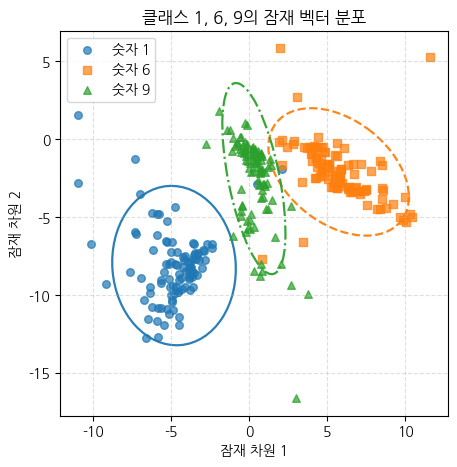

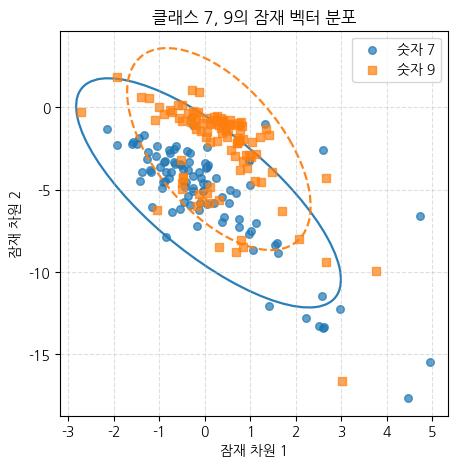

In [10]:
# 그림 7-12 - 잠재 벡터 분포 시각화
import numpy as np

# 각 클래스에서 num_per_class개의 샘플에 대응하는 잠재 벡터를 수집
def collect_z_by_class(model, dataset, classes, num_per_class, device):
    model.eval()
    collected = {c: [] for c in classes}
    with torch.no_grad():
        for img, label in dataset:
            if label in collected and len(collected[label]) < num_per_class:
                z = model.encoder(img.unsqueeze(0).to(device))[0].cpu()
                collected[label].append(z)
            if all(len(v) >= num_per_class for v in collected.values()):
                break
    return collected

# 그림 7-12의 왼쪽 그림: 1, 6, 9 각 100 샘플의 잠재 벡터 시각화
classes_left = [1, 6, 9]
data_left = collect_z_by_class(model, test_set, classes_left, 100, device)

X_left = np.array([z.numpy() for c in classes_left for z in data_left[c]])
y_left = np.array([
    classes_left.index(c) for c in classes_left for _ in range(100)
])

viz.plot_scatter(
    X_left, y_left,
    title='클래스 1, 6, 9의 잠재 벡터 분포',
    x_label='잠재 차원 1', y_label='잠재 차원 2',
    class_names=[f'숫자 {c}' for c in classes_left],
    add_ellipses=True, ellipse_confidence=0.90,
    figsize=(5, 5)
)

# 그림 7-12의 오른쪽 그림: 7, 9 각 100 샘플의 잠재 벡터 시각화
classes_right = [7, 9]
data_right = collect_z_by_class(model, test_set, classes_right, 100, device)

X_right = np.array([z.numpy() for c in classes_right for z in data_right[c]])
y_right = np.array([
    classes_right.index(c) for c in classes_right for _ in range(100)
])

viz.plot_scatter(
    X_right, y_right,
    title='클래스 7, 9의 잠재 벡터 분포',
    x_label='잠재 차원 1', y_label='잠재 차원 2',
    class_names=[f'숫자 {c}' for c in classes_right],
    add_ellipses=True, ellipse_confidence=0.90,
    figsize=(5, 5)
)

In [27]:
common.set_seed()

42

왼쪽 그림에서 1, 6, 9 의 세 군집은 비교적 잘 분리된다. 반면 오른쪽 그림에서 7 과 9 의 영역은 거의 같은 좌표 공간을 공유한다. 이는 본문 설명대로 z_size=2 의 잠재 공간이 너무 작아 형태가 비슷한 숫자(7 과 9) 의 차이를 펼칠 자리가 부족하다는 사실을 보여 준다.

## [코드 7-10] 특징 추출 방식의 전이 학습 분류기

In [11]:
###############################################################################
# 코드 7-10 - 특징 추출 방식의 전이 학습 분류기
###############################################################################
import copy, torchinfo

# 특징 추출 방식으로 오토인코더의 인코더를 재활용하는 분류기 클래스
class ClassifierWithFeatureExtractor(nn.Module):
    def __init__(self, encoder, z_size):
        super().__init__()
        # 사전 학습된 인코더(원본 보존을 위한 깊은 복사)
        self.encoder = copy.deepcopy(encoder)
        # 파라미터 고정(고정하지 않으면 미세 조정 방식의 전이 학습)
        for param in self.encoder.parameters():
            param.requires_grad = False
        # 숫자 분류를 위한 분류기 계층 추가(10개 클래스로 분류)
        self.classifier = nn.Linear(z_size, 10)

    def forward(self, x):                    # x: (784,)
        z_vector = self.encoder(x)           #    -> (z_size,)
        return self.classifier(z_vector)     #    -> (10,)


# 사전 학습된 모델의 인코더(model.encoder)를 주입해 모델 객체 생성(z_size=2)
#     model: 7-3절에서 학습한 MNIST 오토인코더
#     model_fe: 분류기 모델, fe는 feature extractor(특징 추출기)의 약자
model_fe = ClassifierWithFeatureExtractor(model.encoder, Z_SIZE).to(device)

# 옵티마이저: model_fe.parameters()에는 인코더의 파라미터도 포함되지만,
#             requires_grad=False 로 고정되어 있으므로 최적화되지 않음
optimizer_fe = optim.Adam(model_fe.parameters(), lr=LR)

# 모델 정보 확인: 배치 크기를 10 으로 가정
torchinfo.summary(model_fe, input_size=(10, 784), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ClassifierWithFeatureExtractor           [10, 10]                  --
├─Sequential: 1-1                        [10, 2]                   --
│    └─Linear: 2-1                       [10, 128]                 (100,480)
│    └─ReLU: 2-2                         [10, 128]                 --
│    └─Linear: 2-3                       [10, 64]                  (8,256)
│    └─ReLU: 2-4                         [10, 64]                  --
│    └─Linear: 2-5                       [10, 2]                   (130)
├─Linear: 1-2                            [10, 10]                  30
Total params: 108,896
Trainable params: 30
Non-trainable params: 108,866
Total mult-adds (Units.MEGABYTES): 1.09
Input size (MB): 0.03
Forward/backward pass size (MB): 0.02
Params size (MB): 0.44
Estimated Total Size (MB): 0.48

## 참고 - 미세 조정 방식의 전이 학습 분류기

In [29]:
# 참고 - 미세 조정 방식의 전이 학습 분류기
# 미세 조정 방식으로 오토인코더의 인코더를 재활용하는 분류기 클래스
class ClassifierWithFineTuning(nn.Module):
    def __init__(self, encoder, z_size):
        super().__init__()
        self.encoder = copy.deepcopy(encoder)
        # 인코더의 파라미터도 최적화하므로 requires_grad=False 로 고정하지 않는다.
        self.classifier = nn.Linear(z_size, 10)

    def forward(self, x):                    # 입력: (784,)
        z_vector = self.encoder(x)           # (784,) -> (z_size,)
        return self.classifier(z_vector)     # (z_size,) -> (10,)


# 모델 객체 생성
model_ft = ClassifierWithFineTuning(model.encoder, Z_SIZE).to(device)

## [코드 7-11] 계층별 학습률 옵티마이저

In [30]:
###############################################################################
# 코드 7-11 - 계층마다 다른 학습률을 적용하는 옵티마이저 생성
###############################################################################
LR_FT = 1e-5                            # 사전 학습된 계층에 적용할 학습률

# 미세 조정 방식의 옵티마이저
optimizer_ft = optim.Adam(
    [
        # 사전 학습된 계층의 파라미터는 낮은 학습률 지정
        {'params': model_ft.encoder.parameters(), 'lr': LR_FT},
        # 추가 계층의 파라미터는 통상 학습률 지정
        {'params': model_ft.classifier.parameters(), 'lr': LR},
    ]
)

## [코드 7-12] 전이 학습용 데이터셋과 데이터로더

> 컨벤션 정리: 본문은 분할 크기 리스트를 `n_samples`, 배치 크기를 `batch_size` 로 둔다. §3.3(개수에 `n_` 접두 금지) 과 §4.1 에 따라 노트북에서는 분할 크기를 `split_sizes`, 배치 크기를 상수 `BATCH_SIZE_TL` 로 둔다.

In [31]:
###############################################################################
# 코드 7-12 - 전이 학습용 데이터셋과 데이터로더 생성
###############################################################################
# 전이 학습용 데이터셋 생성
split_sizes = [100, 100, 9800]          # 학습, 검증, 평가 데이터셋의 샘플 수

# test_set: 7-3 절의 데이터 변환 객체를 적용한 MNIST 기본 평가 데이터셋
train_set_tl, valid_set_tl, test_set_tl = random_split(
    test_set, split_sizes,
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE_TL = 10                      # 배치 크기

# 전이 학습용 데이터로더
train_loader_tl = DataLoader(train_set_tl, batch_size=BATCH_SIZE_TL, 
                             shuffle=True)
valid_loader_tl = DataLoader(valid_set_tl, batch_size=BATCH_SIZE_TL, 
                             shuffle=False)
test_loader_tl  = DataLoader(test_set_tl,  batch_size=BATCH_SIZE_TL, 
                             shuffle=False)

print(f'전이 학습 - 훈련: {len(train_set_tl)}, '
      f'검증: {len(valid_set_tl)}, '
      f'평가: {len(test_set_tl)}')

전이 학습 - 훈련: 100, 검증: 100, 평가: 9800


## 참고 - 전이 학습 분류기 학습 함수와 학습 진행

분류 모델용 학습 함수(`train_epoch_cls` / `evaluate_cls` / `train_loop_cls`) 를 정의해 두 전이 학습 모델을 같은 환경으로 학습한다.

In [32]:
# 참고 - 분류 모델용 학습 함수 (조기 종료 포함)
def train_epoch_cls(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (logits.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size * 100


@torch.no_grad()
def evaluate_cls(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (logits.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size * 100


def train_loop_cls(model, train_loader, valid_loader, criterion, optimizer,
                   epochs, device, patience=20):
    '''조기 종료 분류 학습 루프. 학습 로그를 담은 EpochLogger를 반환.

    분류이므로 훈련 손실·검증 손실·정확도(%) 세 열을 기록한다(§7.6). 정확도는
    백분율 수(0~100)로 전달한다. 최적 가중치 복원 동작은 그대로 유지한다.
    [표 7-3] 은 반환된 log.history 에서 에포크별 값을 꺼내 재구성한다.
    '''
    model.to(device)
    log = common.EpochLogger(
        epochs, columns=('훈련 손실', '검증 손실', '정확도(%)'),
        formats=('{:.4f}', '{:.4f}', '{:.2f}%'),
    )
    best_loss = float('inf')
    best_epoch = -1
    best_state = None
    counter = 0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch_cls(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss, valid_acc = evaluate_cls(
            model, valid_loader, criterion, device,
        )
        log.row(epoch, train_loss, valid_loss, valid_acc)
        # 정확도 비교용으로 훈련 정확도도 별도로 모아 둠
        log.train_accs = getattr(log, 'train_accs', [])
        log.train_accs.append(train_acc)
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_epoch = epoch
            best_state = {k: v.clone()
                          for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break
    if best_state is not None:
        print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_loss:.4f})로 복원')
        model.load_state_dict(best_state)
    log.best_epoch = best_epoch
    log.best_loss = best_loss
    return log

특징 추출 방식 전이 학습
    epoch    훈련 손실    검증 손실    정확도(%)     시간
   1/1000       3.7117       2.9595       25.00%     0:00
 100/1000       1.4957       1.6240       44.00%     0:04
 200/1000       1.3674       1.5496       45.00%     0:09
 300/1000       1.3014       1.5136       48.00%     0:14
 400/1000       1.2607       1.4909       49.00%     0:19
 500/1000       1.2330       1.4771       49.00%     0:24
 600/1000       1.2130       1.4686       52.00%     0:29
 700/1000       1.1985       1.4626       53.00%     0:34
최적 712 에포크 모델(검증 손실: 1.4614)로 복원


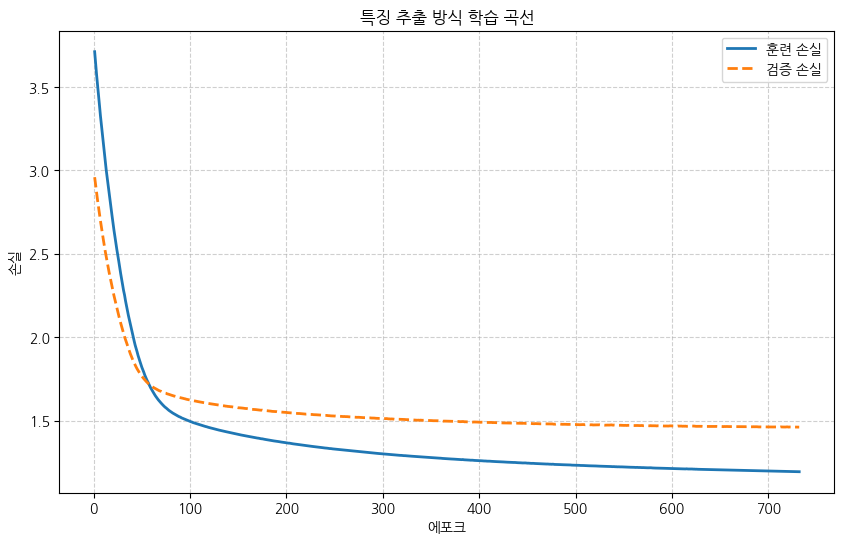

미세 조정 방식 전이 학습
  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/500       4.6737       4.2306       16.00%     0:00
 50/500       2.2848       2.3081       27.00%     0:03
100/500       1.5593       1.7697       43.00%     0:06
150/500       1.3740       1.6596       46.00%     0:08
200/500       1.2529       1.5903       52.00%     0:12
250/500       1.1425       1.5369       56.00%     0:15
300/500       1.0418       1.4999       57.00%     0:18
350/500       0.9479       1.4820       57.00%     0:21
최적 363 에포크 모델(검증 손실: 1.4797)로 복원


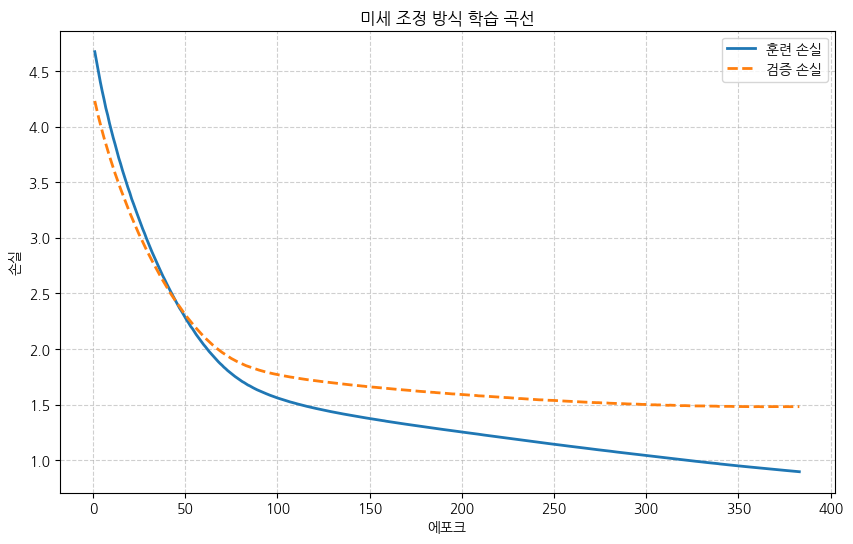

In [33]:
# 참고 - 두 전이 학습 모델 학습
# 본문 [표 7-3] 의 최적 에포크가 303, 362 인 점을 고려해 epochs=500 으로 설정
common.set_seed()

criterion_cls = nn.CrossEntropyLoss()

print('특징 추출 방식 전이 학습')
log_fe = train_loop_cls(
    model_fe, train_loader_tl, valid_loader_tl, criterion_cls, optimizer_fe,
    epochs=1000, device=device, patience=20
)
log_fe.plot(title='특징 추출 방식 학습 곡선')

# 미세 조정 모델은 옵티마이저 재생성 (학습률 그룹 적용)
optimizer_ft = optim.Adam(
    [
        {'params': model_ft.encoder.parameters(), 'lr': LR_FT},
        {'params': model_ft.classifier.parameters(), 'lr': LR},
    ]
)
print('미세 조정 방식 전이 학습')
log_ft = train_loop_cls(
    model_ft, train_loader_tl, valid_loader_tl, criterion_cls, optimizer_ft,
    epochs=500, device=device, patience=20
)
log_ft.plot(title='미세 조정 방식 학습 곡선')

In [34]:
# 참고 - 평가 데이터셋 정확도 ([표 7-3])
fe_test_loss, fe_test_acc = evaluate_cls(
    model_fe, test_loader_tl, criterion_cls, device,
)
ft_test_loss, ft_test_acc = evaluate_cls(
    model_ft, test_loader_tl, criterion_cls, device,
)

print('--- 두 전이 학습 모델의 학습 결과 ([표 7-3]) ---')
header = (f'{"방식":>8s} | {"최적":>5s} | {"훈련손실":>8s} | '
         f'{"검증손실":>8s} | {"훈련정확도":>9s} | {"평가정확도":>9s}')
print(header)
print('-' * len(header))
# 각 EpochLogger가 누적한 이력(log.history)에서 최적 에포크 시점의 값을 꺼낸다.
fe_train_loss = log_fe.history['훈련 손실'][log_fe.best_epoch - 1]
fe_train_acc = log_fe.train_accs[log_fe.best_epoch - 1]
print(f'{"특징 추출":>8s} | {log_fe.best_epoch:>5d} | '
      f'{fe_train_loss:>8.4f} | {log_fe.best_loss:>8.4f} | '
      f'{fe_train_acc:>8.2f}% | {fe_test_acc:>8.2f}%')
ft_train_loss = log_ft.history['훈련 손실'][log_ft.best_epoch - 1]
ft_train_acc = log_ft.train_accs[log_ft.best_epoch - 1]
print(f'{"미세 조정":>8s} | {log_ft.best_epoch:>5d} | '
      f'{ft_train_loss:>8.4f} | {log_ft.best_loss:>8.4f} | '
      f'{ft_train_acc:>8.2f}% | {ft_test_acc:>8.2f}%')

--- 두 전이 학습 모델의 학습 결과 ([표 7-3]) ---
      방식 |    최적 |     훈련손실 |     검증손실 |     훈련정확도 |     평가정확도
--------------------------------------------------------------
   특징 추출 |   712 |   1.1971 |   1.4614 |    60.00% |    56.51%
   미세 조정 |   363 |   0.9267 |   1.4797 |    67.00% |    57.85%


본문 [표 7-3] 의 수치 (특징 추출: 훈련 60.00% / 평가 56.51%, 미세 조정: 훈련 67.00% / 평가 57.85%) 와 비교한다. 시드와 환경 차이로 정확히 일치하지 않을 수 있지만, 두 방식 모두 "극단적으로 적은 100 샘플에서 어떻게든 학습되어 50~60% 대 정확도를 낸다" 는 본문 결론은 동일하게 관찰된다.

## [그림 7-14] 두 전이 학습 모델의 혼동 행렬

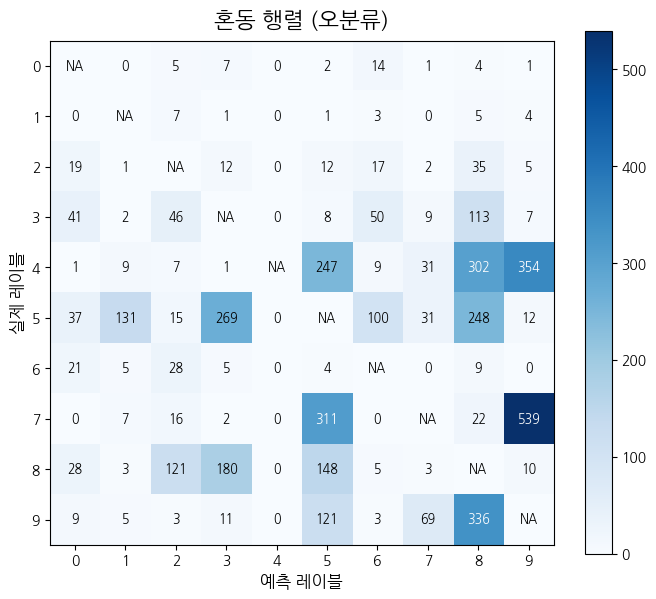

In [35]:
# 참고 - 두 모델의 혼동 행렬 ([그림 7-14])
cm_fe = common.get_confusion_matrix(
    model_fe, test_loader_tl, num_classes=10, device=device,
)

# 노트북 커널에 캐시된 모듈을 최신 코드로 갱신
import importlib
importlib.reload(viz)
# reload 는 모듈 전역 설정을 초기화하므로 저장 설정을 다시 켠다.
viz.configure(save_grayscale=False)

viz.plot_confusion_matrix(
    cm_fe, class_names=list('0123456789'),
    show_errors_only=True
)

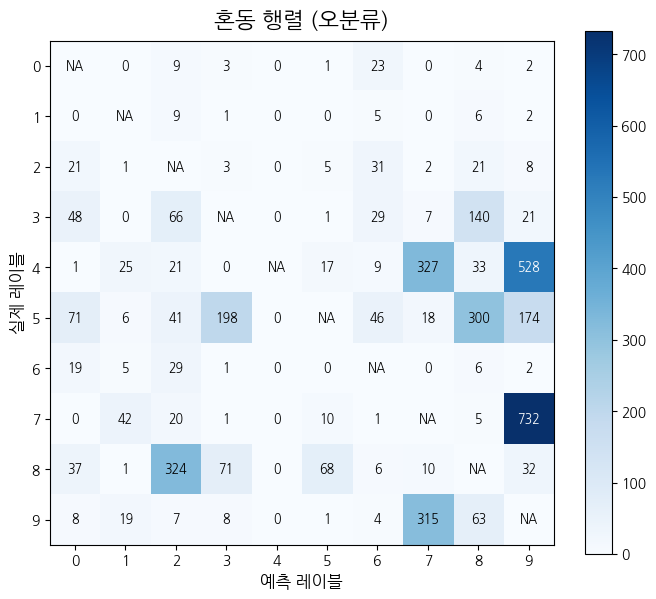

In [36]:
# 참고 - 미세 조정 모델의 혼동 행렬
cm_ft = common.get_confusion_matrix(
    model_ft, test_loader_tl, num_classes=10, device=device,
)
viz.plot_confusion_matrix(
    cm_ft, class_names=list('0123456789'),
    show_errors_only=True
)

본문 설명대로 두 혼동 행렬에서 다음 패턴을 관찰할 수 있다.
- **숫자 7 → 9 오분류 다수**: 잠재 벡터 크기 2 로 인해 7 과 9 의 군집이 거의 겹쳐 있어서.
- **숫자 1 은 잘 분류**: 형태가 단순하고 다른 숫자와 잘 분리되어 있어서.
- **4 → 9, 5 → 3 또는 8 등 형태적으로 닮은 숫자 간 혼동**.

미세 조정 방식은 인코더 파라미터까지 함께 조정해 잠재 공간을 분류에 맞게 재배치하므로, 두 혼동 행렬의 오분류 패턴이 서로 달라진다. 예를 들어 특징 추출에서 두드러지던 4 → 8 오분류는 미세 조정 후 거의 사라지는 대신 8 → 2, 9 → 7 혼동이 새로 늘어난다. 다만 크기 2 의 좁은 잠재 공간에서는 혼동의 총량이 크게 줄지 않아 정확도 개선폭은 작다.

## 정리

- 잠재 공간에 데이터셋 전체의 잠재 벡터를 모아 시각화하면 클래스가 군집을 이루는 모습을 확인할 수 있다. "이 이미지는 1 이다" 같은 정답을 알려준 적이 없음에도 인코더가 클래스별 군집을 자연스럽게 형성한다는 사실은 잠재 공간이 분류기로 재활용할 수 있는 핵심 정보를 담고 있다는 증거이다.
- 전이 학습은 사전 학습된 모델의 일부(예: 인코더) 를 다른 목적에 재활용한다. 특징 추출 방식은 사전 학습 파라미터를 고정하고, 미세 조정 방식은 함께 학습하되 매우 작은 학습률을 사용한다.
- 본 예제에서는 잠재 벡터 크기 2 와 100 개 훈련 샘플이라는 극단적인 조건 때문에 정확도가 50~60% 대에 그치지만, 잠재 크기와 데이터 양을 늘리면 본격적인 전이 학습의 성능을 확인할 수 있다 (연습 7-11, 7-12).

In [37]:
# 참고 - 훈련 데이터셋 클래스별 샘플 수
from collections import Counter

label_counts = Counter(int(train_set_tl[i][1]) for i in range(len(train_set_tl)))
print('--- 훈련 데이터셋 클래스별 샘플 수 ---')
for cls in sorted(label_counts):
    print(f'  숫자 {cls}: {label_counts[cls]:,}')
print(f'  합계: {sum(label_counts.values()):,}')

--- 훈련 데이터셋 클래스별 샘플 수 ---
  숫자 0: 11
  숫자 1: 14
  숫자 2: 12
  숫자 3: 6
  숫자 4: 8
  숫자 5: 8
  숫자 6: 11
  숫자 7: 9
  숫자 8: 11
  숫자 9: 10
  합계: 100


## 참고 - [연습 문제 7-17] 어휘 사전이 다를 때 임베딩 행렬 재구성

[연습 문제 7-17] 은 7-2 절에서 '오즈의 마법사' 로 학습한 임베딩을 '이상한 나라의 앨리스' 학습에 재활용(전이)하는 도전 문제다. 본문은 "임베딩을 가지고 와서 사용하는 경우, 어휘 사전을 재구성하고 어휘 사전의 순서에 맞게 임베딩 행렬도 재구성해야 한다" 고 안내하며 그 과정을 이 노트북에 정리한다고 미뤘다.

핵심은 **두 텍스트의 토큰(어휘) 구성이 달라** 어휘 사전의 순서가 바뀐다는 점이다. 임베딩 행렬은 "행 번호 = 토큰 고유 번호" 규칙으로 동작하므로, 어휘 순서가 바뀌면 같은 토큰이라도 담당하는 행이 달라진다. 따라서 사전 학습된 임베딩을 그대로 쓸 수 없고 다음과 같이 행을 재배치해야 한다.

- **두 어휘에 공통인 토큰**: 사전 학습된 행(벡터)을 새 어휘 순서의 위치로 그대로 이식한다.
- **새 텍스트에만 있는 토큰**: 대응하는 사전 학습 벡터가 없으므로 무작위로 초기화하고 이후 미세 조정으로 학습한다. (본문이 특징 추출이 아니라 미세 조정 방식을 권하는 이유다.)

아래는 이 재구성 과정을 작은 합성 예시로 보여 준다.

In [38]:
# 참고 - [연습 문제 7-17] 어휘 사전이 다를 때 임베딩 행렬 재구성 (작은 합성 예시)
import torch
import torch.nn as nn

torch.manual_seed(SEED)

# 1) '오즈의 마법사' 로 학습했다고 가정한 사전 학습 임베딩 (5 토큰 x 4 차원)
old_vocab = {'the': 0, 'lion': 1, 'oz': 2, 'scarecrow': 3, 'witch': 4}
old_embedding = torch.randn(len(old_vocab), 4)
print(f'[사전 학습 - 오즈] 어휘 사전: {old_vocab}')
print(f'[사전 학습 - 오즈] 임베딩 행렬 형태: {tuple(old_embedding.shape)}')
print()

# 2) '이상한 나라의 앨리스' 토큰 (오즈와 겹치는 토큰 + 새 토큰) -> 정렬 시 순서가 달라진다
alice_tokens = ['alice', 'the', 'rabbit', 'oz', 'queen']
new_vocab = {t: i for i, t in enumerate(sorted(set(alice_tokens)))}
print(f'[전이 대상 - 앨리스] 새 어휘 사전: {new_vocab}')
print()

# 3) 새 어휘 순서에 맞춰 임베딩 행렬 재구성
#    - 공통 토큰: 사전 학습된 행(벡터)을 그대로 이식
#    - 새 토큰: 무작위 초기화 (이후 미세 조정으로 학습)
embedding_dim = old_embedding.shape[1]
new_embedding = torch.randn(len(new_vocab), embedding_dim)
copied, fresh = [], []
for token, new_idx in new_vocab.items():
    if token in old_vocab:
        new_embedding[new_idx] = old_embedding[old_vocab[token]]
        copied.append(token)
    else:
        fresh.append(token)
print(f'사전 학습 벡터를 이식한 토큰: {copied}')
print(f'새로 초기화한 토큰        : {fresh}')
print()

# 4) 재구성한 행렬을 임베딩 계층 가중치로 적재해 미세 조정 준비
embedding_layer = nn.Embedding(len(new_vocab), embedding_dim)
embedding_layer.weight.data.copy_(new_embedding)

# 검증: 공통 토큰 'oz' 의 벡터가 사전 학습 값 그대로 이식됐는지 확인
oz_old = old_embedding[old_vocab['oz']]
oz_new = embedding_layer.weight.data[new_vocab['oz']]
print(f"공통 토큰 'oz' 벡터 보존: {torch.allclose(oz_old, oz_new)}")
print(f"  - 사전 학습(행 {old_vocab['oz']}): {[round(v, 3) for v in oz_old.tolist()]}")
print(f"  - 재구성  (행 {new_vocab['oz']}): {[round(v, 3) for v in oz_new.tolist()]}")

[사전 학습 - 오즈] 어휘 사전: {'the': 0, 'lion': 1, 'oz': 2, 'scarecrow': 3, 'witch': 4}
[사전 학습 - 오즈] 임베딩 행렬 형태: (5, 4)

[전이 대상 - 앨리스] 새 어휘 사전: {'alice': 0, 'oz': 1, 'queen': 2, 'rabbit': 3, 'the': 4}

사전 학습 벡터를 이식한 토큰: ['oz', 'the']
새로 초기화한 토큰        : ['alice', 'queen', 'rabbit']

공통 토큰 'oz' 벡터 보존: True
  - 사전 학습(행 2): [0.356, -0.687, -0.493, 0.241]
  - 재구성  (행 1): [0.356, -0.687, -0.493, 0.241]
